In [17]:
import numpy as np
import matplotlib.pyplot as plt

import cobra
import pandas as pd
import pickle

In [2]:
# Load the model
# Path relative to this notebook
model = cobra.io.read_sbml_model("../../model.xml")

In [6]:
# Load the media definitions
# Path relative to this notebook
with open("../../test/test_files/media/media_definitions.pkl", "rb") as f:
    media_definitions = pickle.load(f)

In [8]:
# Set the model's medium to the minimal glucose medium
model.medium = media_definitions["minimal_glucose"]

In [21]:
# Define the ED reaction ID
ed_rxn = model.reactions.rxn01477_c0
# Define the biomass reaction ID
biomass_rxn = "bio1_biomass"
# Define a reaction to indicate flux through the EMP
emp_rxn = model.reactions.rxn00558_c0

In [36]:
# For a range of ED use values, optimize the model and record the growth rate
ed_use = np.linspace(0, 10, 10)
results = []
for use in ed_use:
    ed_rxn.lower_bound = use
    sol = cobra.flux_analysis.pfba(model)
    results_dict = {
        "ed_use": use,
        "ed_percent": sol.fluxes[ed_rxn.id] / (sol.fluxes[ed_rxn.id] + sol.fluxes[emp_rxn.id]) * 100,
        "growth_rate": sol.fluxes[biomass_rxn],
        "cue" : 1 - (sol.fluxes["EX_cpd00011_e0"] / abs(sol.fluxes["EX_cpd00027_e0"] * 6))
    }
    results.append(results_dict)
# Convert results to a dataframe
results_df = pd.DataFrame(results)

In [37]:
results_df.head()

,ed_use,ed_percent,growth_rate,cue
0,0.000000,0.000000,0.805539,0.619394
1,1.111111,11.111111,0.796588,0.619919
2,2.222222,22.222222,0.787638,0.620444
3,3.333333,33.333333,0.778688,0.620969
4,4.444444,44.444444,0.769737,0.621495


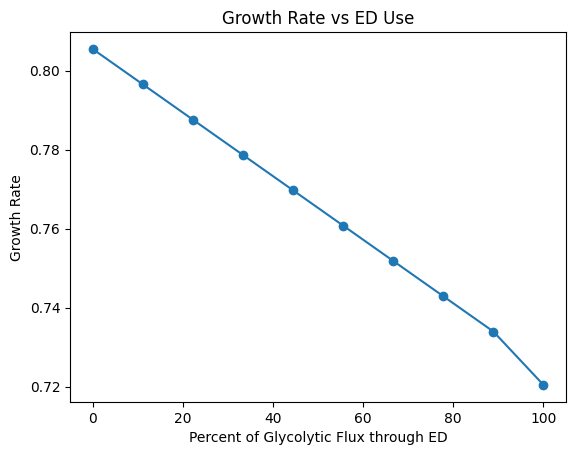

In [28]:
plt.plot(results_df["ed_percent"], results_df["growth_rate"], marker="o")
plt.xlabel("Percent of Glycolytic Flux through ED")
plt.ylabel("Growth Rate")
plt.title("Growth Rate vs ED Use")
plt.show()

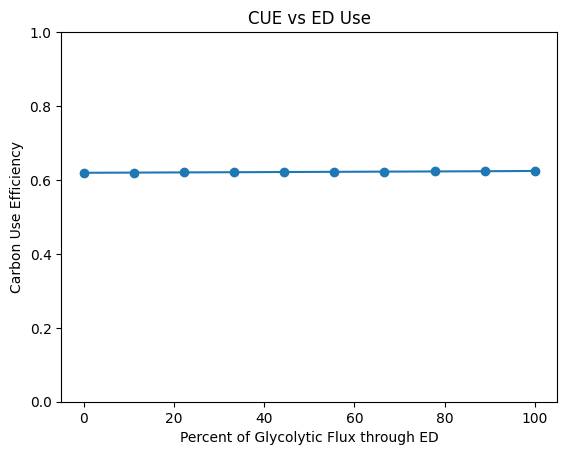

In [40]:
plt.plot(results_df["ed_percent"], results_df["cue"], marker="o")
plt.xlabel("Percent of Glycolytic Flux through ED")
plt.ylim(0, 1)
plt.ylabel("Carbon Use Efficiency")
plt.title("CUE vs ED Use")
plt.show()